<h1 style="color: #0D47A1; font-weight: bold">
    Entrega TP3
</h1>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np

In [27]:
sys.path.append("..")

from src.utils.plotting import (plot_random_images, plot_training_history)
from src.utils.preprocessing import (data_split, scaler)
from src.models.layers import DenseLayer
from src.models.neural_network import SecuentialNeuralNetwork
from src.models.activations import ReLU, SoftMax
from src.models.optimizers import GradientDescent
from src.models.loss import CrossEntropy

<h2 style="color: #1976D2; font-weight: 500">
    1. Análisis exploratorio y preprocesamiento
</h2>

In [4]:
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

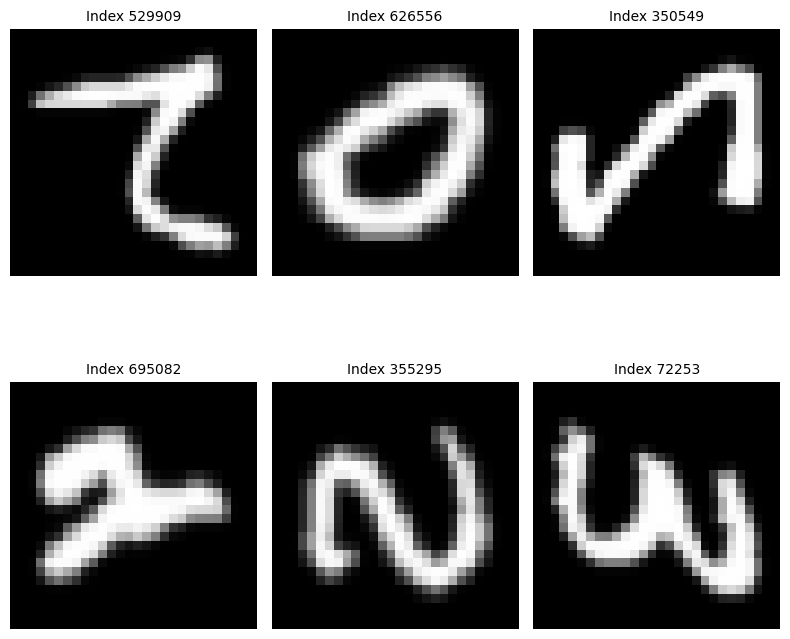

In [5]:
plot_random_images(X_images, image_shape=(28, 28), n=6)

In [6]:
X_images = X_images.reshape(X_images.shape[0], -1)

Cantidad de clases

In [7]:
output_dim = len(set(y_images.tolist()))
print("Cantidad de clases:", output_dim)

Cantidad de clases: 47


In [8]:
input_dim = X_images.shape[1]
print("Cantidad de 'features':", input_dim)

Cantidad de 'features': 784


Normalizo el dataset dividiendo por 255 así el máximo es 1.

Luego:

Dividir en Train, Validation y Test
- Dev 0.9, Test 0.1
- Train 7/9 de Dev, Val 2/9 de Dev

Sobre el dataset total:
- Train 0.7, Val 0.2, Test 0.1

In [9]:
X_images = scaler(X_images)

# Shuffle and split
X_dev, y_dev, X_test, y_test = data_split(X_images, y_images, frac=0.8)
X_train, y_train, X_val, y_val = data_split(X_dev, y_dev, frac=7/9)

<h2 style="color: #1976D2; font-weight: 500">
    2. Implementación y Entrenamiento de una Red Neuronal Básica
</h2>

Incisos **a** y **b** en `src/models/`

**Modelo M0**

- 1ra capa oculta:
    - 128 nodos con activación ReLU
- 2da capa oculta:
    - 64 nodos con activación ReLU
- Capa de salida:
    - 1 nodo con activación SoftMax

In [30]:
layers_m0 = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m0 = SecuentialNeuralNetwork(
    layers_m0, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

Entrenamiento del modelo

In [ ]:
m0.fit(X=X_train, y=y_train, epochs=10, batch_size=128, X_val=X_val, y_val=y_val)

Training: 100%|██████████| 10/10 [02:01<00:00, 12.17s/ep]


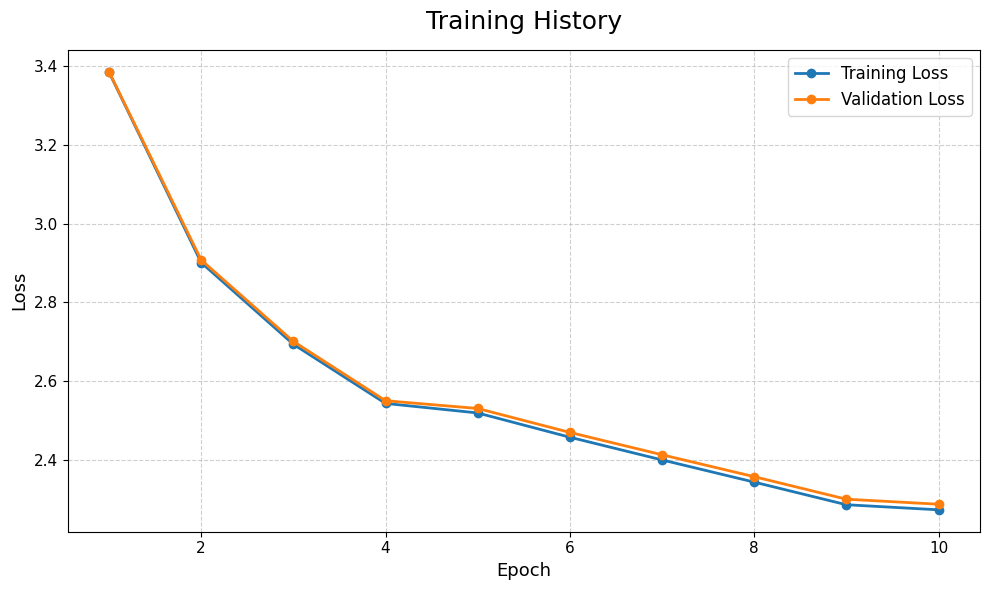

In [32]:
plot_training_history(m0.fit_loss, m0.val_loss)

<h2 style="color: #1976D2; font-weight: 500">
    3. Implementación y Entrenamiento de una Red Neuronal Avanzada
</h2>

<h2 style="color: #1976D2; font-weight: 500">
    4. Desarrollo de una Red Neuronal con PyTorch
</h2>